In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5ab005b337573253183e1e86a289f81d61e750aed6257865309c21456e7ed2e9
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from lime.lime_text import LimeTextExplainer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import OrderedDict

In [5]:
train_df=pd.read_csv('/content/train.csv')
print(f"Train shape: {train_df.shape}")
print(train_df.sample(5))

Train shape: (1306122, 3)
                          qid  ... target
720157   8cfa83cabfa5fd897c24  ...      0
905661   b177b60696ea33359e14  ...      0
1194251  ea0e88385202b6eb0691  ...      0
321857   3f13700e0ed42d02cd78  ...      0
576950   710b9830fe5f1e4f874b  ...      0

[5 rows x 3 columns]


In [7]:
nan_rows = train_df[train_df.isna().any(axis = 1)]
print(nan_rows)

Empty DataFrame
Columns: [qid, question_text, target]
Index: []


In [8]:
train_df = train_df.dropna()
print(train_df.shape)

(1306122, 3)


In [9]:
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

In [11]:
print(val_df.head())

                          qid  ... target
443046   56d324bb1e2c29f43b12  ...      0
947549   b9ad893dc78c577f8a63  ...      0
523769   6689ebaeeb65b209a412  ...      0
949821   ba1e2c4a0fef09671516  ...      0
1030397  c9ea2b69bf0d74626f46  ...      0

[5 rows x 3 columns]


In [13]:
df_select = pd.concat([val_df[val_df['qid']=='6689ebaeeb65b209a412'], val_df[val_df['qid']=='c9ea2b69bf0d74626f46']])

In [14]:
df_select.question_text

,question_text
523769,How can I make friends as a college junior?
1030397,"Like Kuvera, is ""Groww"" also a free online inv..."


In [15]:
val_df.reset_index(drop=True, inplace=True)
print(val_df)

                         qid  ... target
0       56d324bb1e2c29f43b12  ...      0
1       b9ad893dc78c577f8a63  ...      0
2       6689ebaeeb65b209a412  ...      0
3       ba1e2c4a0fef09671516  ...      0
4       c9ea2b69bf0d74626f46  ...      0
...                      ...  ...    ...
261220  f6c8ba137152ba994151  ...      0
261221  121794600ebe90533fb8  ...      0
261222  d2fcceacb58a80a3897e  ...      0
261223  ff96a1b6bdca93125941  ...      0
261224  e52bb5b10ee124e61384  ...      0

[261225 rows x 3 columns]


In [19]:
tfidf_vc  = TfidfVectorizer(min_df=10, max_features=100000, analyzer="word", ngram_range=(1,2), stop_words='english')
train_vc = tfidf_vc.fit_transform(train_df["question_text"])
val_vc = tfidf_vc.transform(val_df["question_text"])

In [20]:
model = LogisticRegression(C=0.5, max_iter=1000, solver="sag")
model = model.fit(train_vc, train_df.target)

val_pred = model.predict(val_vc)

In [22]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(val_df.target, val_pred)
precision = precision_score(val_df.target, val_pred)
recall = recall_score(val_df.target, val_pred)
f1 = f1_score(val_df.target, val_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"f1 Score: {f1}")

Accuracy: 0.9511953296966217
Precision: 0.6936308114171756
Recall: 0.3509712411705348
f1 Score: 0.4660999204321789


In [23]:
con_matrix = confusion_matrix(val_df.target, val_pred)
print(f"Confusion Matrix: \n{con_matrix}")

Confusion Matrix: 
[[242911   2458]
 [ 10291   5565]]


In [24]:
class_names = ["Sincere", "Insincere"]
class_report = classification_report(val_df.target, val_pred, target_names=class_names)
print(f"Classification Report: \n{class_report}")

Classification Report: 
              precision    recall  f1-score   support

     Sincere       0.96      0.99      0.97    245369
   Insincere       0.69      0.35      0.47     15856

    accuracy                           0.95    261225
   macro avg       0.83      0.67      0.72    261225
weighted avg       0.94      0.95      0.94    261225



In [25]:
target_1_rows = val_df[val_df['target']==1]

print(f"Rows with target=1: \n{target_1_rows}")
print(f"\nRow indiced of rows with target as 1: \n{target_1_rows.index.tolist()}")

Rows with target=1: 
                         qid  ... target
58      8786fa2e795d2d0e1440  ...      1
80      cf41b3cc824bdc767b4b  ...      1
94      52f6ab5f791a072d930c  ...      1
96      0609338dee541a017b5f  ...      1
100     b1f5208e0f44556a5964  ...      1
...                      ...  ...    ...
261173  9d75e8c74b4241225717  ...      1
261175  73b89122796995f32150  ...      1
261199  74aa14a448b3d2d3d151  ...      1
261203  a1f73a85c5e5289d85e3  ...      1
261212  8591386fbfe4ef49e9ff  ...      1

[15856 rows x 3 columns]

Row indiced of rows with target as 1: 
[58, 80, 94, 96, 100, 129, 130, 139, 144, 167, 182, 185, 187, 190, 192, 214, 216, 241, 287, 297, 300, 315, 346, 392, 400, 401, 436, 443, 466, 473, 490, 511, 515, 524, 587, 607, 611, 613, 648, 652, 654, 668, 673, 676, 688, 714, 725, 744, 745, 773, 781, 809, 821, 834, 848, 871, 876, 884, 889, 898, 906, 911, 916, 933, 951, 955, 992, 1027, 1040, 1045, 1070, 1078, 1110, 1119, 1126, 1132, 1133, 1163, 1203, 1204, 1211, 1252,

In [46]:
import numpy as np
prediction_index = 1040
idx = int(val_df.index[prediction_index])

c=make_pipeline(tfidf_vc, model)
class_names = ["sincere", "insincere"]

explainer = LimeTextExplainer(class_names = class_names)

exp = explainer.explain_instance(val_df.question_text[idx], c.predict_proba, num_features = 10)

print(val_df["question_text"][idx])
print(f"Probability(Insincere): {c.predict_proba([val_df["question_text"][idx]])[0,1]}")
print(f"Probability(Sincere): {c.predict_proba([val_df["question_text"][idx]])[0,0]}")
print(f"True Class is: {class_names[int(val_df["target"][idx])]}")

Why are Iranians so afraid of sexuality, that it's almost a taboo subject, so much so that they would be happiest human beings if sexuality did not exist?
Probability(Insincere): 0.08062115348054248
Probability(Sincere): 0.9193788465194576
True Class is: insincere


In [47]:
exp.as_list()

[(np.str_('Iranians'), 0.06000764785281867),
 (np.str_('human'), 0.030151818092540958),
 (np.str_('subject'), -0.023018655900752017),
 (np.str_('happiest'), -0.019269850892876618),
 (np.str_('taboo'), -0.013393538004479835),
 (np.str_('afraid'), 0.008616074217217806),
 (np.str_('exist'), -0.0065789358533669745),
 (np.str_('sexuality'), -0.005823731090702879),
 (np.str_('beings'), 0.002360284670978541),
 (np.str_('not'), -0.0011564020297999526)]

In [50]:
print(f"Original Prediction: {model.predict_proba(val_vc[prediction_index])[0,1]}")

tmp = val_vc[prediction_index].copy()
tmp[0, tfidf_vc.vocabulary_['taboo']]=0
tmp[0, tfidf_vc.vocabulary_['subject']]=0

print(f"Prediction afer removing some features: {model.predict_proba(tmp)[0,1]}")
print(f"Difference: {model.predict_proba(tmp)[0,1] - model.predict_proba(val_vc[prediction_index])[0,1]}")

Original Prediction: 0.08062115348054248
Prediction afer removing some features: 0.09879894467542386
Difference: 0.018177791194881374


In [51]:
exp.show_in_notebook(text=val_df["question_text"][idx], labels=(1,))

/tmp/ipykernel_863/4237171102.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="words", y="weights", data=lime_weights, palette="viridis")


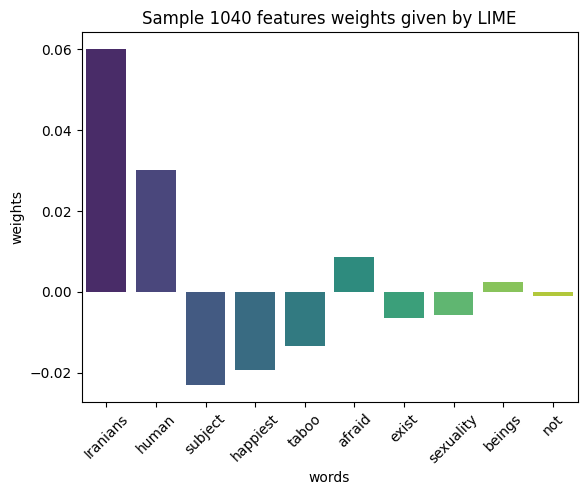

In [52]:
weights = OrderedDict(exp.as_list())
lime_weights = pd.DataFrame({"words": list(weights.keys()), "weights": list(weights.values())})

sns.barplot(x="words", y="weights", data=lime_weights, palette="viridis")
plt.xticks(rotation=45)
plt.title("Sample {} features weights given by LIME".format(idx))
plt.show()